# F2 — Análisis Exploratorio de Datos (EDA)

Notebook orquestador de la **Fase 2** del bloque ML. Cubre las tareas:

- **F2-T1** — series, estadísticas, distribuciones, NaN.
- **F2-T2** — stylized facts en datos reales (kurtosis, ACF, leverage effect).
- **F2-T3** — análisis macro y regímenes (VIX, TNX, DXY).
- **F2-T4** — sub-períodos de estrés del test.
- **F2-T5** — correlaciones cruzadas train vs test.

Los hallazgos se sintetizan en `outputs/eda/eda_summary.md` (F2-T6) y
se validan vía `tests/test_stylized_facts.py` (F2-T7).

**Insumo**: `data/processed/aligned.parquet` producido por F1.
**Convención**: las columnas safe-filename (sin caret) son `GSPC`, `NDX`, `AAPL`, `AMZN`, `NFLX`, `NVDA`; precios ajustados con sufijo `_AdjClose`.

## Setup

Imports, paths y constantes que compartirán todas las secciones.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yaml

# Permite importar src/ aunque el notebook se ejecute desde notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.eval.stylized_facts import (
    log_returns,
    compute_stylized_facts,
    plot_acf_panel,
)

ALIGNED_PATH = PROJECT_ROOT / 'data' / 'processed' / 'aligned.parquet'
OUT_EDA = PROJECT_ROOT / 'outputs' / 'eda'
OUT_FIGS = OUT_EDA / 'figs'
OUT_FIGS.mkdir(parents=True, exist_ok=True)

EQUITIES = ['GSPC', 'NDX', 'AAPL', 'AMZN', 'NFLX', 'NVDA']
MACROS = ['VIX', 'TNX', 'DXY']

# Splits cronológicos (consistentes con plan maestro — se formalizan en F3-T5).
TRAIN_END = '2021-12-31'
VAL_END = '2022-12-31'
TEST_START = '2023-01-01'

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110


In [2]:
df = pd.read_parquet(ALIGNED_PATH)
df.columns.name = None  # quita metadata 'Price' del nivel de columnas
print(f'shape: {df.shape}')
print(f'rango fechas: {df.index.min().date()} → {df.index.max().date()}')
df.head(3)

shape: (2597, 39)
rango fechas: 2015-01-02 → 2025-04-30


,GSPC_AdjClose,GSPC_Close,GSPC_High,GSPC_Low,GSPC_Open,GSPC_Volume,NDX_AdjClose,NDX_Close,NDX_High,NDX_Low,...,NFLX_Volume,NVDA_AdjClose,NVDA_Close,NVDA_High,NVDA_Low,NVDA_Open,NVDA_Volume,VIX_Close,TNX_Close,DXY_Close
date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,2058.199951,2058.199951,2072.360107,2046.040039,2058.899902,2708700000,4230.240234,4230.240234,4276.709961,4206.459961,...,134750000,0.482985,0.50325,0.50700,0.49525,0.50325,113680000,17.790001,2.123,91.080002
2015-01-05,2020.579956,2020.579956,2054.439941,2017.339966,2054.439941,3799120000,4160.959961,4160.959961,4210.959961,4151.850098,...,181650000,0.474828,0.49475,0.50475,0.49250,0.50325,197952000,19.920000,2.039,91.379997
2015-01-06,2002.609985,2002.609985,2030.250000,1992.439941,2022.150024,4460110000,4110.830078,4110.830078,4176.259766,4090.330078,...,160377000,0.460432,0.47975,0.49600,0.47925,0.49550,197764000,21.120001,1.963,91.500000


## 1. Series, estadísticas, distribuciones y NaN  *(F2-T1)*

Cuatro entregables visuales:
1. Panel 2×3 de cierres ajustados (escala log) con marcas de COVID 2020 y rally 2023-2024.
2. Tabla `describe()` por activo con fechas inicio/fin.
3. Histograma de log-returns con normal sobreimpuesta — debe verse exceso de kurtosis.
4. Tabla `% NaN` (sanity check de F1).

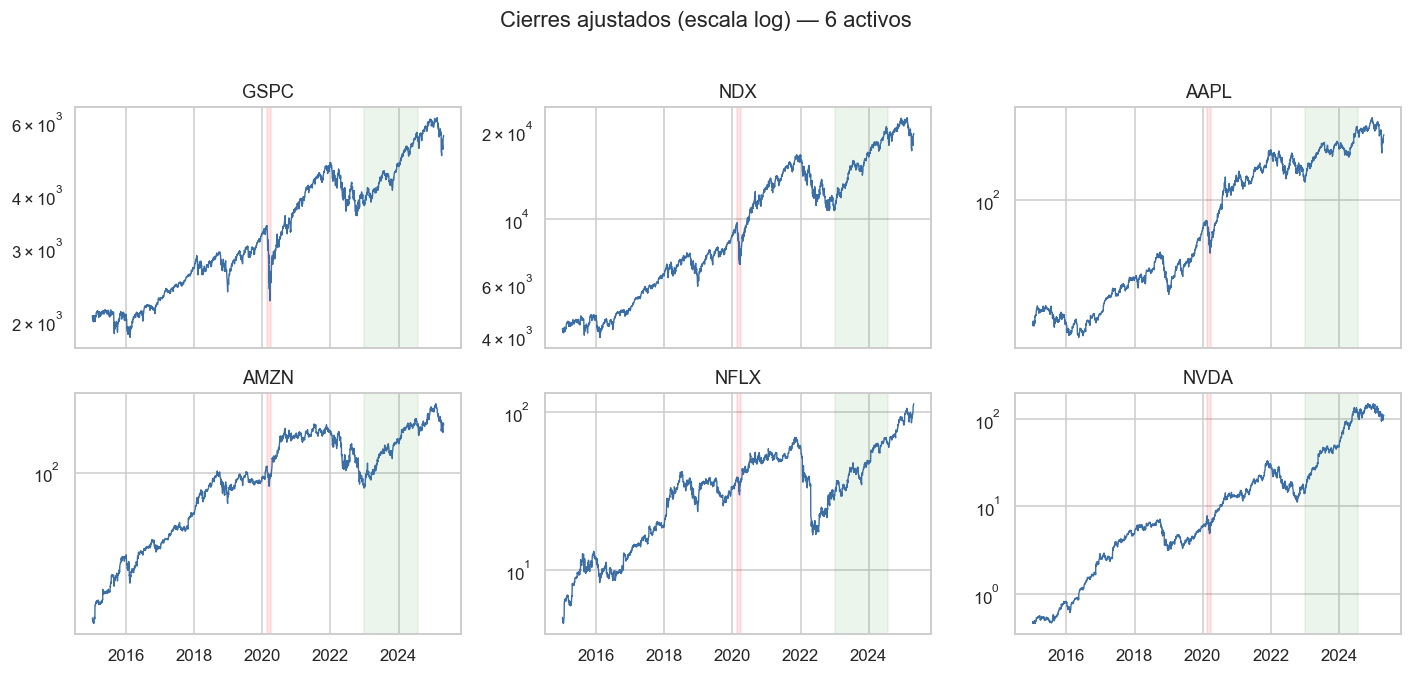

In [3]:
adj_close = df[[f'{t}_AdjClose' for t in EQUITIES]]
adj_close.columns = EQUITIES  # nombres limpios para los plots

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True)
for ax, ticker in zip(axes.flatten(), EQUITIES):
    ax.plot(adj_close.index, adj_close[ticker], color='#3b6ea5', lw=0.9)
    ax.set_yscale('log')
    ax.set_title(ticker)
    ax.axvspan(pd.Timestamp('2020-02-19'), pd.Timestamp('2020-04-01'),
               color='red', alpha=0.10, label='COVID crash')
    ax.axvspan(pd.Timestamp('2023-01-01'), pd.Timestamp('2024-07-31'),
               color='green', alpha=0.08, label='AI rally')
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('Cierres ajustados (escala log) — 6 activos', y=1.02)
fig.tight_layout()
fig.savefig(OUT_FIGS / 'prices_panel.png', bbox_inches='tight')
plt.show()

In [4]:
summary = adj_close.describe().T
summary['start'] = adj_close.apply(lambda c: c.first_valid_index())
summary['end'] = adj_close.apply(lambda c: c.last_valid_index())
summary[['count', 'mean', 'std', 'min', 'max', 'start', 'end']].round(2)

,count,mean,std,min,max,start,end
GSPC,2597.0,3431.06,1146.87,1829.08,6144.15,2015-01-02,2025-04-30
NDX,2597.0,10339.17,5067.76,3947.80,22175.60,2015-01-02,2025-04-30
AAPL,2597.0,97.70,68.15,20.57,257.38,2015-01-02,2025-04-30
AMZN,2597.0,104.55,56.57,14.35,242.06,2015-01-02,2025-04-30
NFLX,2597.0,35.54,21.63,4.55,113.17,2015-01-02,2025-04-30
NVDA,2597.0,23.92,36.36,0.46,149.38,2015-01-02,2025-04-30


returns shape: (2596, 6)


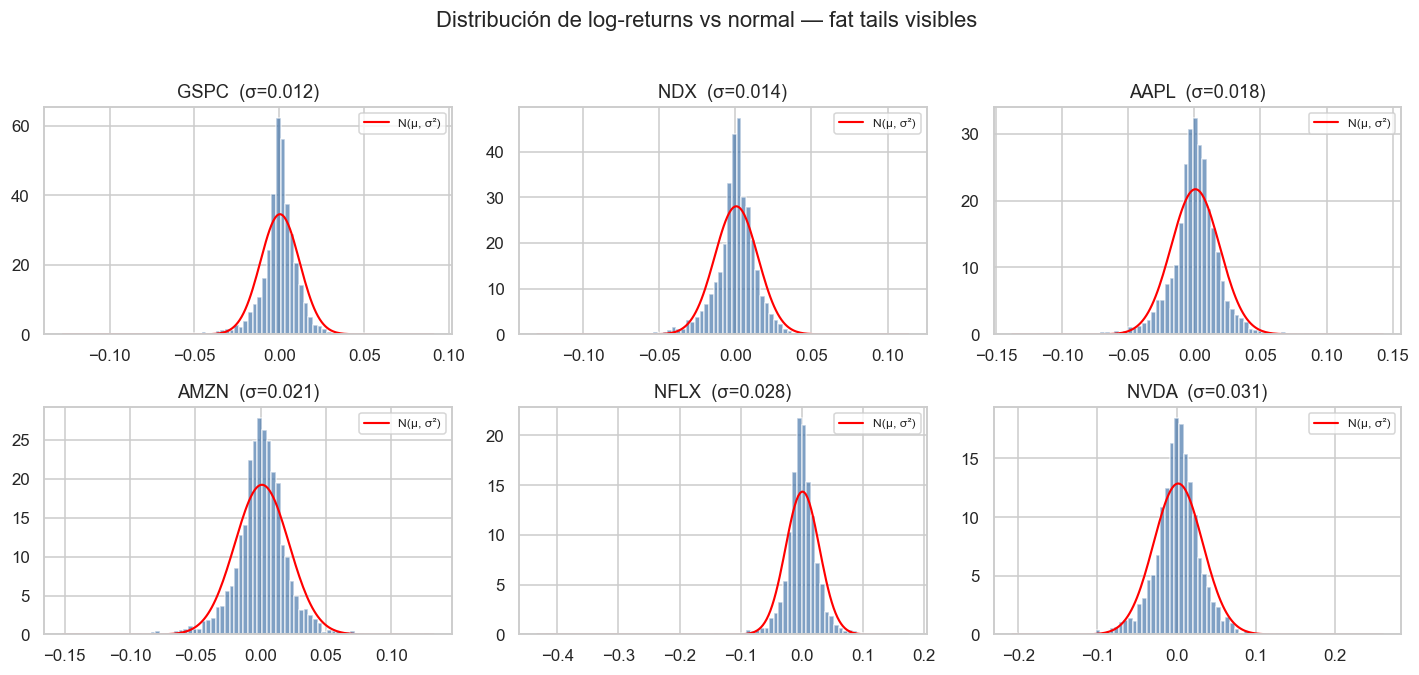

In [5]:
returns = log_returns(adj_close)
print(f'returns shape: {returns.shape}')

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=False)
for ax, ticker in zip(axes.flatten(), EQUITIES):
    sample = returns[ticker].dropna().to_numpy()
    ax.hist(sample, bins=80, density=True, color='#3b6ea5', alpha=0.65)
    mu, sigma = sample.mean(), sample.std()
    xs = np.linspace(sample.min(), sample.max(), 200)
    pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs - mu) / sigma) ** 2)
    ax.plot(xs, pdf, color='red', lw=1.4, label='N(μ, σ²)')
    ax.set_title(f'{ticker}  (σ={sigma:.3f})')
    ax.legend(fontsize=8)
fig.suptitle('Distribución de log-returns vs normal — fat tails visibles', y=1.02)
fig.tight_layout()
fig.savefig(OUT_FIGS / 'returns_hist_panel.png', bbox_inches='tight')
plt.show()

In [6]:
nan_pct = 100 * df.isna().sum() / len(df)
nan_bad = nan_pct[nan_pct > 0]
if nan_bad.empty:
    print('✓ 0% NaN en todas las columnas (sanity check F1 OK)')
else:
    print('⚠ NaN detectado:')
    display(nan_bad)

✓ 0% NaN en todas las columnas (sanity check F1 OK)


## 2. Stylized facts en datos reales  *(F2-T2)*

Caracterización cuantitativa de los retornos reales. Esta tabla es la **vara de medir** contra la que se evaluarán los sintéticos de TimeGAN en F4-T11.

**Hipótesis** (que el test F2-T7 valida):
- `kurtosis > 3` en todos los activos (fat tails).
- `ACF(|r|, lag=1) > ACF(r, lag=1)` (volatility clustering domina sobre autocorrelación lineal).
- `leverage_effect_k5 < 0` (caídas hoy → mayor volatilidad mañana).

In [7]:
facts = compute_stylized_facts(returns)
facts.round(4)

,kurtosis,skew,shapiro_pvalue,acf_ret_lag1,acf_abs_ret_lag1,leverage_effect_k5
asset,,,,,,
GSPC,18.6127,-0.6511,0.0,-0.1336,0.3772,-0.1258
NDX,10.8993,-0.3680,0.0,-0.1235,0.2902,-0.0998
AAPL,9.3425,-0.1108,0.0,-0.0628,0.2311,-0.0729
AMZN,8.7783,0.1658,0.0,-0.0184,0.1934,-0.0538
NFLX,32.0176,-1.3383,0.0,-0.0060,0.1110,-0.0354
NVDA,9.8203,0.1411,0.0,-0.0738,0.1722,-0.0614


In [8]:
CSV_PATH = OUT_EDA / 'stylized_facts_real.csv'
facts.to_csv(CSV_PATH)
print(f'Persistido en {CSV_PATH.relative_to(PROJECT_ROOT)}')

fig_paths = plot_acf_panel(returns, OUT_FIGS, max_lag=30)
print(f'Generadas {len(fig_paths)} figuras ACF en {OUT_FIGS.relative_to(PROJECT_ROOT)}/')

Persistido en outputs/eda/stylized_facts_real.csv


Generadas 6 figuras ACF en outputs/eda/figs/


### Sanity check: ¿dependen los stylized facts del shock COVID?

Pitfall #3 del plan maestro: el período mar–jun 2020 distorsiona kurtosis globales. Repetimos la tabla excluyéndolo. Si los facts se mantienen, la presencia de fat tails es estructural, no un artefacto del shock.

In [9]:
mask_no_covid = ~returns.index.to_series().between('2020-03-01', '2020-06-30')
facts_no_covid = compute_stylized_facts(returns.loc[mask_no_covid])
compare = pd.concat(
    [facts.add_suffix('_full'), facts_no_covid.add_suffix('_no_covid')],
    axis=1,
)
compare[[c for c in compare.columns if c.startswith(('kurtosis', 'acf_'))]].round(4)

,kurtosis_full,acf_ret_lag1_full,acf_abs_ret_lag1_full,kurtosis_no_covid,acf_ret_lag1_no_covid,acf_abs_ret_lag1_no_covid
asset,,,,,,
GSPC,18.6127,-0.1336,0.3772,8.7559,-0.0163,0.2326
NDX,10.8993,-0.1235,0.2902,7.2584,-0.0387,0.1982
AAPL,9.3425,-0.0628,0.2311,7.8458,-0.0034,0.1794
AMZN,8.7783,-0.0184,0.1934,9.1424,-0.0031,0.1755
NFLX,32.0176,-0.0060,0.1110,33.8107,0.0104,0.1005
NVDA,9.8203,-0.0738,0.1722,9.7336,-0.0392,0.1368


## 3. Análisis macro y regímenes  *(F2-T3)*

Características de VIX, TNX, DXY. Identificación de regímenes alta-vol (VIX>25) y correlaciones con los retornos de los activos.

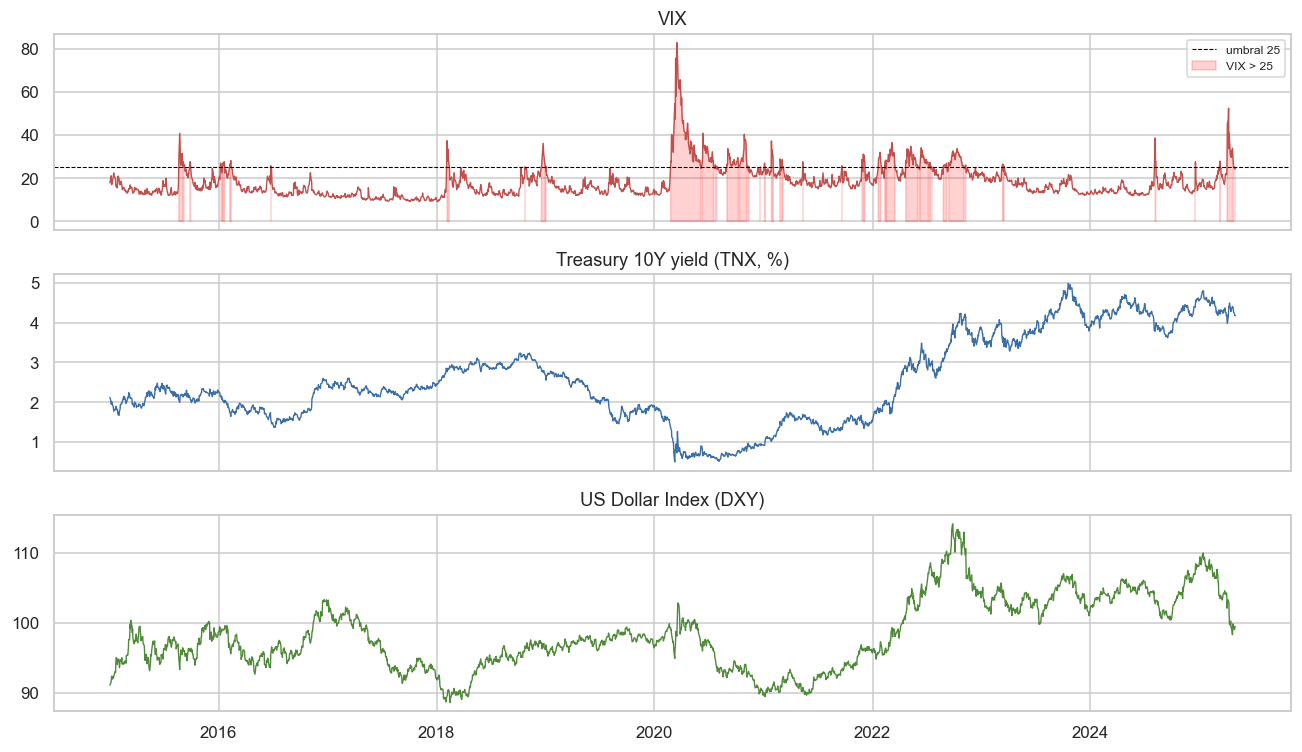

In [10]:
macro = df[[f'{m}_Close' for m in MACROS]].copy()
macro.columns = MACROS

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(macro.index, macro['VIX'], color='#c0504d', lw=0.9)
axes[0].axhline(25, color='black', lw=0.7, ls='--', label='umbral 25')
axes[0].fill_between(macro.index, 0, macro['VIX'], where=(macro['VIX'] > 25),
                     color='red', alpha=0.18, label='VIX > 25')
axes[0].set_title('VIX')
axes[0].legend(loc='upper right', fontsize=8)

axes[1].plot(macro.index, macro['TNX'], color='#3b6ea5', lw=0.9)
axes[1].set_title('Treasury 10Y yield (TNX, %)')

axes[2].plot(macro.index, macro['DXY'], color='#4f8a3a', lw=0.9)
axes[2].set_title('US Dollar Index (DXY)')
fig.tight_layout()
fig.savefig(OUT_FIGS / 'macro_series.png', bbox_inches='tight')
plt.show()

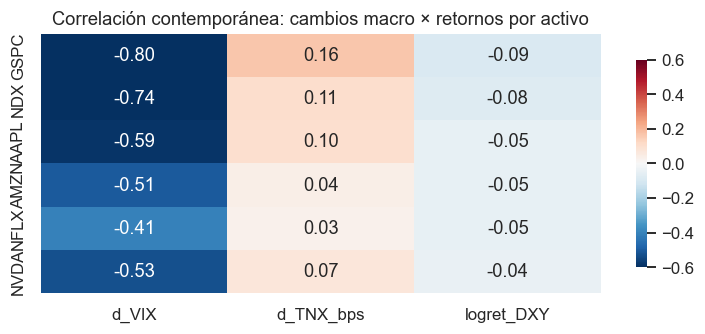

In [11]:
# Transformaciones macro estacionarias (consistentes con plan F3-T4)
macro_changes = pd.DataFrame({
    'd_VIX': macro['VIX'].diff(),
    'd_TNX_bps': macro['TNX'].diff() * 100,  # cambio en pb
    'logret_DXY': np.log(macro['DXY'] / macro['DXY'].shift(1)),
}, index=macro.index)

cross = pd.concat([returns, macro_changes], axis=1).dropna()
corr_cross = cross[EQUITIES].apply(
    lambda col: cross[macro_changes.columns].apply(lambda m: col.corr(m))
).T

fig, ax = plt.subplots(figsize=(7, 3.2))
sns.heatmap(corr_cross, annot=True, fmt='.2f', vmin=-0.6, vmax=0.6,
            cmap='RdBu_r', center=0, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlación contemporánea: cambios macro × retornos por activo')
fig.tight_layout()
fig.savefig(OUT_FIGS / 'cross_macro_returns.png', bbox_inches='tight')
plt.show()

In [12]:
# Correlaciones con lag: macro_t vs returns_{t+k}
lag_rows = []
for k in (1, 5, 10):
    for mcol in macro_changes.columns:
        for tk in EQUITIES:
            joined = pd.concat([macro_changes[mcol], returns[tk].shift(-k)], axis=1).dropna()
            lag_rows.append({
                'lag': k,
                'macro': mcol,
                'asset': tk,
                'corr': joined.corr().iloc[0, 1],
            })
lag_table = pd.DataFrame(lag_rows).pivot_table(index=['macro', 'lag'], columns='asset', values='corr')
lag_table.round(3)

asset            AAPL   AMZN   GSPC    NDX   NFLX   NVDA
macro      lag                                          
d_TNX_bps  1   -0.040 -0.029 -0.058 -0.053 -0.011 -0.042
           5   -0.014 -0.010  0.006 -0.004  0.003  0.008
           10  -0.026 -0.083 -0.034 -0.054 -0.045 -0.049
d_VIX      1    0.094  0.058  0.121  0.125  0.036  0.104
           5   -0.025  0.009 -0.052 -0.026  0.008 -0.030
           10   0.030  0.036  0.040  0.047  0.014  0.032
logret_DXY 1   -0.007 -0.003 -0.022 -0.011 -0.029 -0.007
           5    0.001  0.020  0.045  0.024  0.024  0.005
           10  -0.003 -0.009  0.015  0.006 -0.012 -0.012

In [13]:
def detect_high_vol_periods(vix: pd.Series, *, threshold: float = 25.0,
                            min_duration: int = 5) -> pd.DataFrame:
    """Runs contiguos de días con VIX > threshold. Drop runs cortos."""
    flag = (vix > threshold).astype(int)
    # group_id se incrementa cuando cambia el flag
    group_id = (flag.diff().abs().fillna(0).cumsum())
    runs = []
    for gid, grp in flag.groupby(group_id):
        if grp.iloc[0] == 1 and len(grp) >= min_duration:
            runs.append({
                'start': grp.index[0],
                'end': grp.index[-1],
                'duration_days': int(len(grp)),
            })
    return pd.DataFrame(runs)

high_vol = detect_high_vol_periods(macro['VIX'])

# Métricas del S&P 500 dentro de cada período
sp_close = adj_close['GSPC']
def window_stats(start, end):
    window = sp_close.loc[start:end]
    cum_return = window.iloc[-1] / window.iloc[0] - 1
    peak = window.cummax()
    mdd = float(((window - peak) / peak).min())
    return pd.Series({'sp500_return': cum_return, 'sp500_mdd': mdd})

if not high_vol.empty:
    enriched = high_vol.apply(lambda r: window_stats(r['start'], r['end']), axis=1)
    high_vol = pd.concat([high_vol, enriched], axis=1)
high_vol

,start,end,duration_days,sp500_return,sp500_mdd
0,2015-08-21,2015-09-04,11,-0.025202,-0.052403
1,2016-02-08,2016-02-12,5,0.006118,-0.013143
2,2018-02-05,2018-02-12,6,0.002665,-0.042350
3,2018-12-18,2018-12-31,9,-0.015439,-0.076609
4,2020-02-24,2020-06-04,72,-0.035196,-0.306424
5,2020-06-08,2020-07-17,29,-0.002370,-0.071244
6,2020-08-31,2020-10-08,28,-0.015279,-0.096045
7,2020-10-12,2020-11-05,19,-0.006726,-0.074772
8,2021-01-27,2021-02-02,5,0.020140,-0.019311
9,2021-11-30,2021-12-06,5,0.005402,-0.011815


## 4. Sub-períodos de estrés del test  *(F2-T4)*

Identificamos a priori 3 sub-períodos en el conjunto de test (2023-01-01 → 2025-04-30).
Estos fueron documentados en `configs/eval/stress_subperiods.yaml` y son input directo de la evaluación condicional de F7-T5.

Validamos visualmente que coinciden con regímenes adversos del S&P 500.

In [14]:
with (PROJECT_ROOT / 'configs' / 'eval' / 'stress_subperiods.yaml').open() as fh:
    subperiods_cfg = yaml.safe_load(fh)
subperiods = subperiods_cfg['stress_subperiods']
subperiods

[{'label': 'rates_shock_2023',
  'start': datetime.date(2023, 3, 1),
  'end': datetime.date(2023, 10, 31),
  'rationale': 'Subida agresiva de tipos por la Fed; SVB collapse en marzo; máximos del yield 10Y en octubre.'},
 {'label': 'ai_rally_2024',
  'start': datetime.date(2024, 1, 1),
  'end': datetime.date(2024, 7, 31),
  'rationale': 'Rally tecnológico liderado por NVDA; alta concentración de retornos.'},
 {'label': 'q1_2025_selloff',
  'start': datetime.date(2025, 1, 1),
  'end': datetime.date(2025, 3, 31),
  'rationale': 'Corrección Q1 2025 (confirmar amplitud con datos hasta 2025-04-30).'}]

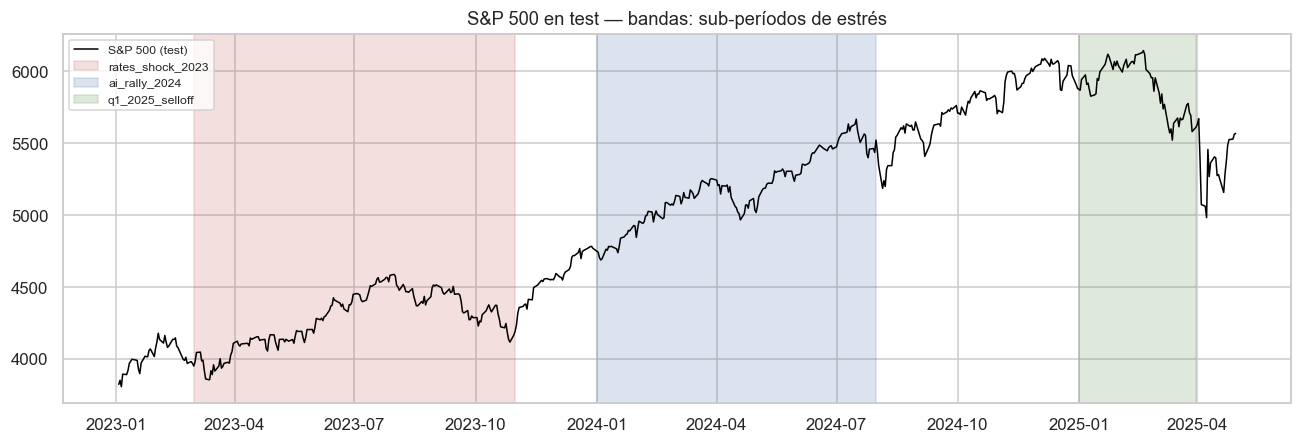

In [15]:
test_sp = sp_close.loc[TEST_START:]

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(test_sp.index, test_sp, color='black', lw=1.0, label='S&P 500 (test)')
colors = ['#c0504d', '#3b6ea5', '#4f8a3a']
for sp, color in zip(subperiods, colors):
    ax.axvspan(pd.Timestamp(sp['start']), pd.Timestamp(sp['end']),
               color=color, alpha=0.18, label=sp['label'])
ax.set_title('S&P 500 en test — bandas: sub-períodos de estrés')
ax.legend(loc='upper left', fontsize=8)
fig.tight_layout()
fig.savefig(OUT_FIGS / 'stress_subperiods.png', bbox_inches='tight')
plt.show()

In [16]:
# Métricas dentro de cada sub-período
rows = []
for sp in subperiods:
    start = pd.Timestamp(sp['start'])
    end = pd.Timestamp(sp['end'])
    window = sp_close.loc[start:end]
    if window.empty:
        rows.append({'label': sp['label'], 'n_days': 0, 'sp500_return': np.nan, 'sp500_mdd': np.nan})
        continue
    cum_return = window.iloc[-1] / window.iloc[0] - 1
    peak = window.cummax()
    mdd = float(((window - peak) / peak).min())
    rows.append({
        'label': sp['label'],
        'n_days': int(len(window)),
        'sp500_return': cum_return,
        'sp500_mdd': mdd,
    })
pd.DataFrame(rows).set_index('label').round(4)

,n_days,sp500_return,sp500_mdd
label,,,
rates_shock_2023,170,0.0613,-0.1028
ai_rally_2024,146,0.1643,-0.0546
q1_2025_selloff,60,-0.0437,-0.1013


## 5. Correlaciones cruzadas train vs test  *(F2-T5)*

¿La estructura de correlaciones entre los 6 activos cambia entre el período de entrenamiento (2015–2021) y el período de test (2023–2025)? Si cambia mucho, la generalización del PPO será más difícil.

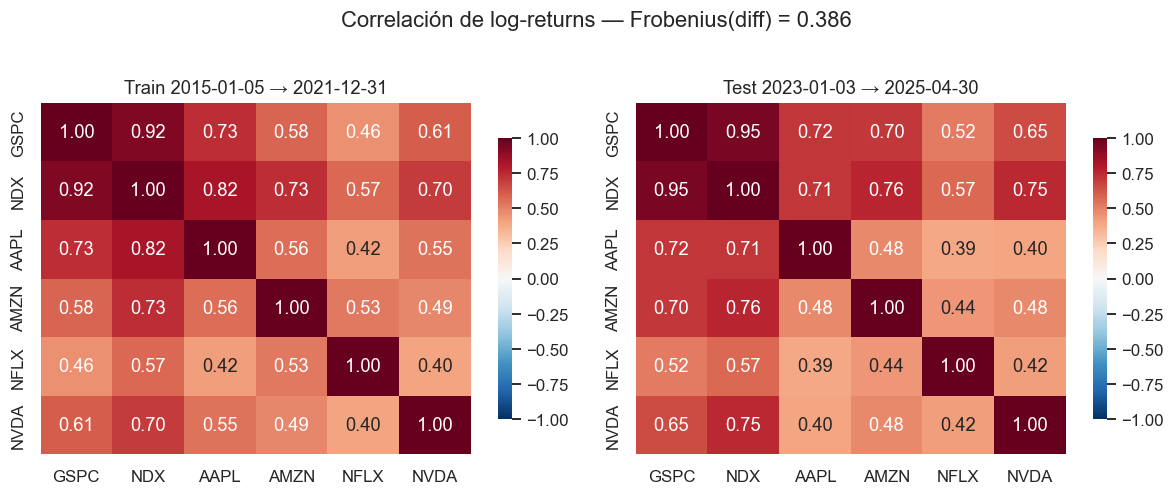

In [17]:
returns_train = returns.loc[:TRAIN_END]
returns_test = returns.loc[TEST_START:]

corr_train = returns_train.corr()
corr_test = returns_test.corr()
frobenius = float(np.linalg.norm(corr_train.values - corr_test.values, ord='fro'))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, mat, title in [
    (axes[0], corr_train, f'Train {returns_train.index.min().date()} → {returns_train.index.max().date()}'),
    (axes[1], corr_test, f'Test {returns_test.index.min().date()} → {returns_test.index.max().date()}'),
]:
    sns.heatmap(mat, annot=True, fmt='.2f', vmin=-1, vmax=1, cmap='RdBu_r',
                center=0, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title(title)
fig.suptitle(f'Correlación de log-returns — Frobenius(diff) = {frobenius:.3f}', y=1.02)
fig.tight_layout()
fig.savefig(OUT_FIGS / 'corr_train_vs_test.png', bbox_inches='tight')
plt.show()

In [18]:
# Diferencias por par de activos
diff = (corr_test - corr_train).round(3)
pairs = []
cols = corr_train.columns.tolist()
for i, a in enumerate(cols):
    for b in cols[i + 1:]:
        pairs.append({
            'pair': f'{a.replace("_AdjClose", "")} ↔ {b.replace("_AdjClose", "")}',
            'corr_train': corr_train.loc[a, b],
            'corr_test': corr_test.loc[a, b],
            'diff': diff.loc[a, b],
        })
pairs_df = pd.DataFrame(pairs).set_index('pair').round(3)
pairs_df.sort_values('diff', key=lambda s: s.abs(), ascending=False)

,corr_train,corr_test,diff
pair,,,
AAPL ↔ NVDA,0.546,0.398,-0.148
GSPC ↔ AMZN,0.580,0.704,0.125
NDX ↔ AAPL,0.823,0.715,-0.108
AMZN ↔ NFLX,0.528,0.442,-0.087
AAPL ↔ AMZN,0.561,0.479,-0.083
GSPC ↔ NFLX,0.457,0.521,0.064
NDX ↔ NVDA,0.702,0.751,0.049
GSPC ↔ NVDA,0.608,0.651,0.043
AAPL ↔ NFLX,0.419,0.389,-0.029


**Interpretación**:
- Frobenius distance reportada arriba.
- Pares con mayor `|diff|` señalan los cambios estructurales más fuertes — útiles para discusión en el Cap. 6 sobre generalización del agente.

---

## Outputs persistidos

Tras ejecutar este notebook, deben existir:
- `outputs/eda/stylized_facts_real.csv` (F2-T2)
- `outputs/eda/figs/acf_*.png` × 6 (F2-T2)
- `outputs/eda/figs/prices_panel.png`, `returns_hist_panel.png`, `macro_series.png`, `cross_macro_returns.png`, `stress_subperiods.png`, `corr_train_vs_test.png`
- `configs/eval/stress_subperiods.yaml` (versionado en repo)
- `outputs/eda/eda_summary.md` (redactado a mano tras revisar el notebook)

El test `tests/test_stylized_facts.py::test_real_data_has_fat_tails` valida los criterios cuantitativos de la sección 2.